#Verificación de GPU

In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de PyTorch: 2.10.0+cu128
GPU disponible: True
GPU: Tesla T4


# Integración y verificación de archivo .JSON de Kaggle

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"axelypr","key":"5e5bb252a8601f4dbba65ed7eda25564"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle --version

Kaggle CLI 2.0.2


# Descarga del dataset

In [5]:
!mkdir -p data/blood_cells
!kaggle datasets download -d paultimothymooney/blood-cells -p data/blood_cells
!unzip -q data/blood_cells/blood-cells.zip -d data/blood_cells

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:07<00:00, 15.6MB/s]



In [6]:
!find data/blood_cells -maxdepth 5 -type d

data/blood_cells
data/blood_cells/dataset-master
data/blood_cells/dataset-master/dataset-master
data/blood_cells/dataset-master/dataset-master/Annotations
data/blood_cells/dataset-master/dataset-master/JPEGImages
data/blood_cells/dataset2-master
data/blood_cells/dataset2-master/dataset2-master
data/blood_cells/dataset2-master/dataset2-master/images
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN

In [7]:
import os

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

print("Existe DATA_DIR:", os.path.exists(DATA_DIR))
print("Carpetas:", os.listdir(DATA_DIR))
print("Clases TRAIN:", os.listdir(os.path.join(DATA_DIR, "TRAIN")))
print("Clases TEST:", os.listdir(os.path.join(DATA_DIR, "TEST")))

Existe DATA_DIR: True
Carpetas: ['TEST_SIMPLE', 'TRAIN', 'TEST']
Clases TRAIN: ['EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'NEUTROPHIL']
Clases TEST: ['EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'NEUTROPHIL']


# Creación de estructura del trabajo

In [8]:
!mkdir -p src
!mkdir -p results/figures
!mkdir -p results/checkpoints
!mkdir -p results/metrics

# Creación de los archivos

In [9]:
%%writefile src/models.py

import torch
import torch.nn as nn


class LeNet5(nn.Module):
    """
    LeNet-5 adaptado para imágenes RGB de 64x64.
    Mantiene 2 bloques conv-pool y 3 capas fully connected.
    """

    def __init__(self, num_classes=4):
        super(LeNet5, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 13 * 13, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class LeNet5BN(nn.Module):
    """
    LeNet-5 adaptado con Batch Normalization después de cada capa convolucional.
    """

    def __init__(self, num_classes=4):
        super(LeNet5BN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 13 * 13, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class VGG11Small(nn.Module):
    """
    VGG-11 simplificado.
    Filtros reducidos a la mitad respecto a VGG-11 original.
    """

    def __init__(self, num_classes=4):
        super(VGG11Small, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class VGG11SmallBN(nn.Module):
    """
    VGG-11 simplificado con Batch Normalization después de cada capa convolucional.
    """

    def __init__(self, num_classes=4):
        super(VGG11SmallBN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Writing src/models.py


In [10]:
%%writefile src/utils.py

import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def set_seed(seed=42):
    """
    Fija semillas para reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def count_parameters(model):
    """
    Cuenta parámetros entrenables.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_data_loaders(data_dir, batch_size=32, img_size=64, val_split=0.2, seed=42):
    """
    Carga TRAIN y TEST usando ImageFolder.
    Divide TRAIN en train/validation.
    """

    train_dir = os.path.join(data_dir, "TRAIN")
    test_dir = os.path.join(data_dir, "TEST")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    full_train_aug = datasets.ImageFolder(train_dir, transform=train_transform)
    full_train_eval = datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

    val_size = int(len(full_train_aug) * val_split)
    train_size = len(full_train_aug) - val_size

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(full_train_aug), generator=generator).tolist()

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_aug, train_indices)
    val_dataset = Subset(full_train_eval, val_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True, num_workers=2,
        pin_memory=True, generator=torch.Generator().manual_seed(seed)
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False, num_workers=2,
        pin_memory=True
    )

    class_names = full_train_aug.classes

    return train_loader, val_loader, test_loader, class_names


def plot_training_curves(history, model_name, save_dir="results/figures"):
    """
    Guarda curvas de pérdida y accuracy.
    """

    os.makedirs(save_dir, exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, f"{model_name}_loss.png"), bbox_inches="tight")
    plt.close()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, f"{model_name}_accuracy.png"), bbox_inches="tight")
    plt.close()

Writing src/utils.py


In [11]:
%%writefile src/train.py

import os
import time
import torch


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


def fit(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    checkpoint_dir="results/checkpoints"
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            checkpoint_path = os.path.join(
                checkpoint_dir,
                f"{model_name}_best.pth"
            )

            torch.save({
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "epoch": epoch + 1
            }, checkpoint_path)

    return history


def load_best_checkpoint(model, checkpoint_path, device):
    """
    Carga el mejor checkpoint guardado durante el entrenamiento.
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    return model

Writing src/train.py


# Tarea 1

## Importación de dependencias

In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

from src.models import LeNet5, LeNet5BN, VGG11Small, VGG11SmallBN
from src.utils import set_seed, get_data_loaders, count_parameters, plot_training_curves
from src.train import fit, evaluate, load_best_checkpoint

## Lectura del dataset y parámetros

In [13]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 15
LR = 0.001

Dispositivo: cuda


## Creación de variables TRAIN y TEST

In [14]:
train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Creación de experimentos

In [15]:
experiments = {
    "LeNet": LeNet5(num_classes=4),
    "LeNet_BN": LeNet5BN(num_classes=4),
    "VGG11Small": VGG11Small(num_classes=4),
    "VGG11Small_BN": VGG11SmallBN(num_classes=4)
}

## Entrenamiento

In [16]:
results = []
histories = {}

criterion = nn.CrossEntropyLoss()

for model_name, model in experiments.items():
    print("=" * 80)
    print(f"Entrenando modelo: {model_name}")
    print("=" * 80)

    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)

    num_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        checkpoint_dir="results/checkpoints"
    )

    histories[model_name] = history

    plot_training_curves(
        history=history,
        model_name=model_name,
        save_dir="results/figures"
    )

    checkpoint_path = f"results/checkpoints/{model_name}_best.pth"
    model = load_best_checkpoint(model, checkpoint_path, device)

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    results.append({
        "Modelo": model_name,
        "Parametros_entrenables": num_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

    print(f"Test Accuracy de {model_name}: {test_acc:.4f}")

Entrenando modelo: LeNet
Epoch [1/15] Train Loss: 1.2651 | Train Acc: 0.3796 | Val Loss: 1.1268 | Val Acc: 0.4847 | Time: 15.02s
Epoch [2/15] Train Loss: 1.0424 | Train Acc: 0.5287 | Val Loss: 1.0016 | Val Acc: 0.5485 | Time: 13.72s
Epoch [3/15] Train Loss: 0.9538 | Train Acc: 0.5645 | Val Loss: 0.9436 | Val Acc: 0.5630 | Time: 13.65s
Epoch [4/15] Train Loss: 0.8804 | Train Acc: 0.5944 | Val Loss: 0.8745 | Val Acc: 0.5726 | Time: 13.44s
Epoch [5/15] Train Loss: 0.7835 | Train Acc: 0.6407 | Val Loss: 0.7678 | Val Acc: 0.6464 | Time: 13.58s
Epoch [6/15] Train Loss: 0.6839 | Train Acc: 0.6833 | Val Loss: 0.6746 | Val Acc: 0.6861 | Time: 13.61s
Epoch [7/15] Train Loss: 0.5836 | Train Acc: 0.7325 | Val Loss: 0.5580 | Val Acc: 0.7393 | Time: 13.72s
Epoch [8/15] Train Loss: 0.5258 | Train Acc: 0.7622 | Val Loss: 0.4936 | Val Acc: 0.7820 | Time: 13.78s
Epoch [9/15] Train Loss: 0.4582 | Train Acc: 0.7894 | Val Loss: 0.4732 | Val Acc: 0.7850 | Time: 13.60s
Epoch [10/15] Train Loss: 0.4319 | Trai

## Verificación de resultados

In [17]:
df_results = pd.DataFrame(results)
df_results

,Modelo,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,LeNet,337976,13.91,0.8262,0.7479,0.7932
1,LeNet_BN,338020,13.52,0.8825,0.5131,3.5496
2,VGG11Small,2963396,14.14,0.3737,0.3438,1.3740
3,VGG11Small_BN,2966148,14.64,0.9754,0.8331,1.3317


In [18]:
df_results.to_csv("results/metrics/tarea1_resultados.csv", index=False)

## Verificación de archivos

In [19]:
!find results -maxdepth 3 -type f

results/figures/VGG11Small_BN_loss.png
results/figures/LeNet_BN_accuracy.png
results/figures/VGG11Small_loss.png
results/figures/VGG11Small_BN_accuracy.png
results/figures/VGG11Small_accuracy.png
results/figures/LeNet_loss.png
results/figures/LeNet_BN_loss.png
results/figures/LeNet_accuracy.png
results/checkpoints/LeNet_BN_best.pth
results/checkpoints/VGG11Small_BN_best.pth
results/checkpoints/VGG11Small_best.pth
results/checkpoints/LeNet_best.pth
results/metrics/tarea1_resultados.csv


# Tarea 2

## Importación de dependencias

In [20]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from src.models import VGG11Small, VGG11SmallBN
from src.utils import set_seed, get_data_loaders, count_parameters
from src.train import fit, evaluate, load_best_checkpoint

## Lectura del dataset y parámetros

In [21]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 10
LR_BASE = 0.001

train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Dispositivo: cuda
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Entrenamiento

In [22]:
learning_rates = [0.001, 0.003, 0.01]

lr_results = []
lr_histories = {}

criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    experiments_lr = {
        f"VGG11Small_sin_BN_LR_{lr}": VGG11Small(num_classes=4),
        f"VGG11Small_con_BN_LR_{lr}": VGG11SmallBN(num_classes=4)
    }

    for model_name, model in experiments_lr.items():
        print("=" * 90)
        print(f"Entrenando: {model_name}")
        print("=" * 90)

        set_seed(42)

        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        num_params = count_parameters(model)

        history = fit(
            model=model,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epochs=EPOCHS,
            checkpoint_dir="results/checkpoints"
        )

        lr_histories[model_name] = history

        checkpoint_path = f"results/checkpoints/{model_name}_best.pth"
        model = load_best_checkpoint(model, checkpoint_path, device)

        test_loss, test_acc, test_preds, test_labels = evaluate(
            model=model,
            data_loader=test_loader,
            criterion=criterion,
            device=device
        )

        avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

        lr_results.append({
            "Modelo": model_name,
            "Batch_Normalization": "con BN" if "con_BN" in model_name else "sin BN",
            "Learning_rate": lr,
            "Parametros_entrenables": num_params,
            "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
            "Best_val_accuracy": round(max(history["val_acc"]), 4),
            "Test_accuracy": round(test_acc, 4),
            "Test_loss": round(test_loss, 4)
        })

df_lr_analysis = pd.DataFrame(lr_results)

os.makedirs("results/metrics", exist_ok=True)
df_lr_analysis.to_csv("results/metrics/tarea2_analisis_learning_rates.csv", index=False)

df_lr_analysis

Entrenando: VGG11Small_sin_BN_LR_0.001
Epoch [1/10] Train Loss: 1.3872 | Train Acc: 0.2453 | Val Loss: 1.3868 | Val Acc: 0.2446 | Time: 14.11s
Epoch [2/10] Train Loss: 1.3867 | Train Acc: 0.2518 | Val Loss: 1.3863 | Val Acc: 0.2557 | Time: 13.91s
Epoch [3/10] Train Loss: 1.3867 | Train Acc: 0.2481 | Val Loss: 1.3864 | Val Acc: 0.2446 | Time: 13.99s
Epoch [4/10] Train Loss: 1.3867 | Train Acc: 0.2530 | Val Loss: 1.3866 | Val Acc: 0.2456 | Time: 14.52s
Epoch [5/10] Train Loss: 1.3868 | Train Acc: 0.2463 | Val Loss: 1.3865 | Val Acc: 0.2446 | Time: 14.53s
Epoch [6/10] Train Loss: 1.3865 | Train Acc: 0.2502 | Val Loss: 1.3863 | Val Acc: 0.2557 | Time: 14.25s
Epoch [7/10] Train Loss: 1.3868 | Train Acc: 0.2483 | Val Loss: 1.3865 | Val Acc: 0.2456 | Time: 13.93s
Epoch [8/10] Train Loss: 1.3866 | Train Acc: 0.2509 | Val Loss: 1.3865 | Val Acc: 0.2446 | Time: 14.06s
Epoch [9/10] Train Loss: 1.3866 | Train Acc: 0.2448 | Val Loss: 1.3863 | Val Acc: 0.2446 | Time: 13.95s
Epoch [10/10] Train Loss:

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,14.13,0.2557,0.2505,1.3864
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,14.43,0.8327,0.8018,0.5163
2,VGG11Small_sin_BN_LR_0.003,sin BN,0.003,2963396,14.03,0.2557,0.2505,1.3868
3,VGG11Small_con_BN_LR_0.003,con BN,0.003,2966148,14.29,0.8614,0.6900,1.0727
4,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,2963396,13.75,0.2557,0.2505,1.3864
5,VGG11Small_con_BN_LR_0.01,con BN,0.010,2966148,14.27,0.7107,0.7193,0.4776


## Gráficas de las curvas

In [23]:
os.makedirs("results/figures", exist_ok=True)

hist_sin_bn = lr_histories["VGG11Small_sin_BN_LR_0.001"]
hist_con_bn = lr_histories["VGG11Small_con_BN_LR_0.001"]

epochs_range = range(1, EPOCHS + 1)

### Pérdida

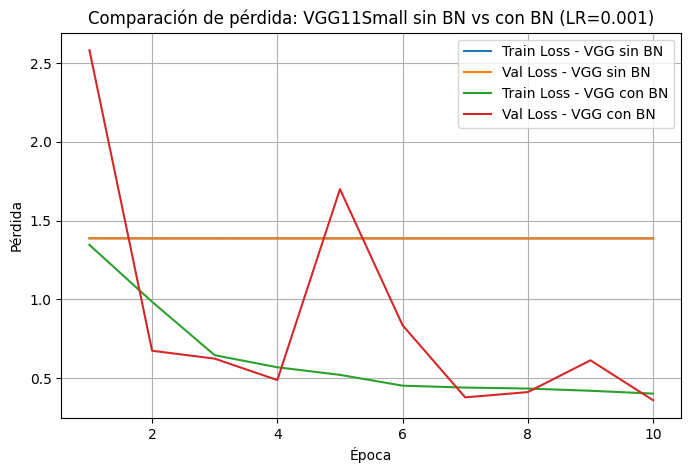

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, hist_sin_bn["train_loss"], label="Train Loss - VGG sin BN")
plt.plot(epochs_range, hist_sin_bn["val_loss"], label="Val Loss - VGG sin BN")

plt.plot(epochs_range, hist_con_bn["train_loss"], label="Train Loss - VGG con BN")
plt.plot(epochs_range, hist_con_bn["val_loss"], label="Val Loss - VGG con BN")

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Comparación de pérdida: VGG11Small sin BN vs con BN (LR=0.001)")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_loss_vgg_bn_lr001.png", bbox_inches="tight")
plt.show()

### Accuracy

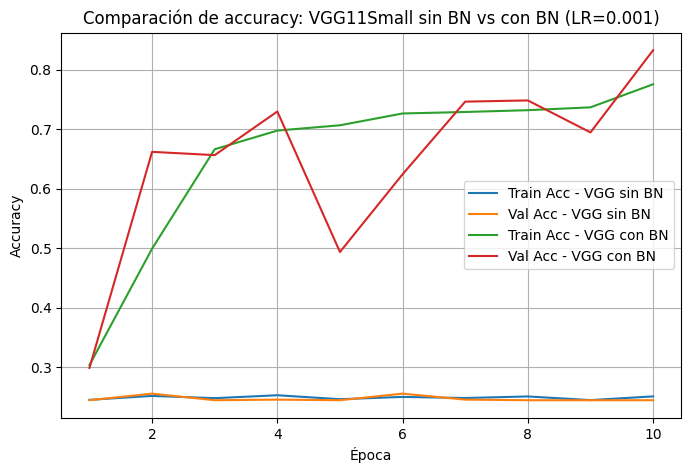

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, hist_sin_bn["train_acc"], label="Train Acc - VGG sin BN")
plt.plot(epochs_range, hist_sin_bn["val_acc"], label="Val Acc - VGG sin BN")

plt.plot(epochs_range, hist_con_bn["train_acc"], label="Train Acc - VGG con BN")
plt.plot(epochs_range, hist_con_bn["val_acc"], label="Val Acc - VGG con BN")

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy: VGG11Small sin BN vs con BN (LR=0.001)")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_accuracy_vgg_bn_lr001.png", bbox_inches="tight")
plt.show()

## Cálculo de épocas hasta llegar al 80%

In [26]:
def epoch_to_reach_accuracy(acc_values, threshold=0.80):
    """
    Devuelve la primera época donde se alcanza el accuracy indicado.
    Si no lo alcanza, devuelve None.
    """
    for idx, acc in enumerate(acc_values):
        if acc >= threshold:
            return idx + 1
    return None


threshold = 0.80

convergence_lr_summary = []

for model_name, history in lr_histories.items():
    train_epoch_80 = epoch_to_reach_accuracy(history["train_acc"], threshold)
    val_epoch_80 = epoch_to_reach_accuracy(history["val_acc"], threshold)

    convergence_lr_summary.append({
        "Modelo": model_name,
        "Learning_rate": float(model_name.split("_LR_")[-1]),
        "Batch_Normalization": "con BN" if "con_BN" in model_name else "sin BN",
        "Epoca_80_train_acc": train_epoch_80 if train_epoch_80 is not None else "No alcanzó",
        "Epoca_80_val_acc": val_epoch_80 if val_epoch_80 is not None else "No alcanzó",
        "Max_train_acc": round(max(history["train_acc"]), 4),
        "Max_val_acc": round(max(history["val_acc"]), 4)
    })

df_convergence_lr = pd.DataFrame(convergence_lr_summary)

df_convergence_lr = df_convergence_lr.sort_values(
    by=["Learning_rate", "Batch_Normalization"]
).reset_index(drop=True)

df_convergence_lr.to_csv(
    "results/metrics/tarea2_convergencia_80_accuracy_lr.csv",
    index=False
)

df_convergence_lr

,Modelo,Learning_rate,Batch_Normalization,Epoca_80_train_acc,Epoca_80_val_acc,Max_train_acc,Max_val_acc
0,VGG11Small_con_BN_LR_0.001,0.001,con BN,No alcanzó,10,0.7755,0.8327
1,VGG11Small_sin_BN_LR_0.001,0.001,sin BN,No alcanzó,No alcanzó,0.2530,0.2557
2,VGG11Small_con_BN_LR_0.003,0.003,con BN,9,10,0.8431,0.8614
3,VGG11Small_sin_BN_LR_0.003,0.003,sin BN,No alcanzó,No alcanzó,0.2552,0.2557
4,VGG11Small_con_BN_LR_0.01,0.010,con BN,No alcanzó,No alcanzó,0.6953,0.7107
5,VGG11Small_sin_BN_LR_0.01,0.010,sin BN,No alcanzó,No alcanzó,0.2498,0.2557


In [27]:
df_convergence_lr_001 = df_convergence_lr[
    df_convergence_lr["Learning_rate"] == 0.001
].reset_index(drop=True)

df_convergence_lr_001

,Modelo,Learning_rate,Batch_Normalization,Epoca_80_train_acc,Epoca_80_val_acc,Max_train_acc,Max_val_acc
0,VGG11Small_con_BN_LR_0.001,0.001,con BN,No alcanzó,10,0.7755,0.8327
1,VGG11Small_sin_BN_LR_0.001,0.001,sin BN,No alcanzó,No alcanzó,0.2530,0.2557


## Gráfica de LR vs Test Accuracy

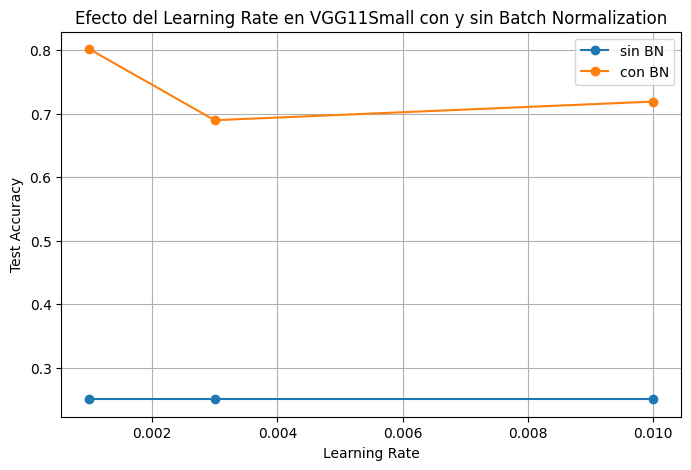

In [28]:
plt.figure(figsize=(8, 5))

for bn_status in ["sin BN", "con BN"]:
    subset = df_lr_analysis[df_lr_analysis["Batch_Normalization"] == bn_status]
    plt.plot(
        subset["Learning_rate"],
        subset["Test_accuracy"],
        marker="o",
        label=bn_status
    )

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("Efecto del Learning Rate en VGG11Small con y sin Batch Normalization")
plt.legend()
plt.grid(True)

plt.savefig("results/figures/tarea2_lr_comparison_accuracy.png", bbox_inches="tight")
plt.show()

## Guardar datos

In [29]:
df_lr_analysis.to_csv("results/metrics/tarea2_analisis_learning_rates.csv", index=False)

df_convergence_lr.to_csv(
    "results/metrics/tarea2_convergencia_80_accuracy_lr.csv",
    index=False
)

In [30]:
df_tarea2_final = df_lr_analysis.copy()
df_tarea2_final.to_csv("results/metrics/tarea2_resultados_finales.csv", index=False)
df_tarea2_final

,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,14.13,0.2557,0.2505,1.3864
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,14.43,0.8327,0.8018,0.5163
2,VGG11Small_sin_BN_LR_0.003,sin BN,0.003,2963396,14.03,0.2557,0.2505,1.3868
3,VGG11Small_con_BN_LR_0.003,con BN,0.003,2966148,14.29,0.8614,0.6900,1.0727
4,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,2963396,13.75,0.2557,0.2505,1.3864
5,VGG11Small_con_BN_LR_0.01,con BN,0.010,2966148,14.27,0.7107,0.7193,0.4776


# Tarea 3

## Importación de dependencias

In [31]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Subset

from src.utils import set_seed, count_parameters, plot_training_curves
from src.train import fit, evaluate, load_best_checkpoint

## Data loaders para ResNet-18

In [32]:
def get_transfer_data_loaders(data_dir, batch_size=32, img_size=224, val_split=0.2, seed=42):
    train_dir = os.path.join(data_dir, "TRAIN")
    test_dir = os.path.join(data_dir, "TEST")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    full_train_aug = datasets.ImageFolder(train_dir, transform=train_transform)
    full_train_eval = datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

    val_size = int(len(full_train_aug) * val_split)
    train_size = len(full_train_aug) - val_size

    generator = torch.Generator().manual_seed(seed)

    indices = torch.randperm(len(full_train_aug), generator=generator).tolist()
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_aug, train_indices)
    val_dataset = Subset(full_train_eval, val_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        generator=torch.Generator().manual_seed(seed)
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    class_names = full_train_aug.classes

    return train_loader, val_loader, test_loader, class_names

## Función para crear ResNet-18 según estrategia

In [33]:
def build_resnet18_transfer(strategy, num_classes=4):
    """
    strategy:
    - feature_extraction
    - fine_tuning_partial
    - fine_tuning_total
    """

    weights = ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if strategy == "feature_extraction":
        # Congelar todo excepto la capa final FC
        for name, param in model.named_parameters():
            param.requires_grad = False

        for param in model.fc.parameters():
            param.requires_grad = True

    elif strategy == "fine_tuning_partial":
        # Congelar capas iniciales
        for name, param in model.named_parameters():
            param.requires_grad = False

        # Entrenar últimos bloques + FC
        for param in model.layer3.parameters():
            param.requires_grad = True

        for param in model.layer4.parameters():
            param.requires_grad = True

        for param in model.fc.parameters():
            param.requires_grad = True

    elif strategy == "fine_tuning_total":
        # Entrenar todo el modelo
        for name, param in model.named_parameters():
            param.requires_grad = True

    else:
        raise ValueError("Estrategia no válida.")

    return model

## Configuración del experimento

In [34]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS_TRANSFER = 8

train_loader_tl, val_loader_tl, test_loader_tl, class_names = get_transfer_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader_tl))
print("Batches val:", len(val_loader_tl))
print("Batches test:", len(test_loader_tl))

Dispositivo: cuda
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Entrenamiento de las 3 estrategias

In [35]:
transfer_experiments = {
    "ResNet18_Feature_Extraction": {
        "strategy": "feature_extraction",
        "lr": 0.001
    },
    "ResNet18_Fine_Tuning_Parcial": {
        "strategy": "fine_tuning_partial",
        "lr": 0.0001
    },
    "ResNet18_Fine_Tuning_Total": {
        "strategy": "fine_tuning_total",
        "lr": 0.00001
    }
}

criterion = nn.CrossEntropyLoss()

transfer_results = []
transfer_histories = {}

for model_name, config in transfer_experiments.items():
    print("=" * 90)
    print(f"Entrenando estrategia: {model_name}")
    print("=" * 90)

    set_seed(42)

    model = build_resnet18_transfer(
        strategy=config["strategy"],
        num_classes=4
    )

    model = model.to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    num_trainable_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader_tl,
        val_loader=val_loader_tl,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS_TRANSFER,
        checkpoint_dir="results/checkpoints"
    )

    transfer_histories[model_name] = history

    plot_training_curves(
        history=history,
        model_name=model_name,
        save_dir="results/figures"
    )

    checkpoint_path = f"results/checkpoints/{model_name}_best.pth"
    model = load_best_checkpoint(model, checkpoint_path, device)

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader_tl,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    transfer_results.append({
        "Modelo": model_name,
        "Estrategia": config["strategy"],
        "Learning_rate": config["lr"],
        "Parametros_entrenables": num_trainable_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

df_transfer = pd.DataFrame(transfer_results)
df_transfer

Entrenando estrategia: ResNet18_Feature_Extraction
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Epoch [1/8] Train Loss: 1.1543 | Train Acc: 0.4982 | Val Loss: 0.9561 | Val Acc: 0.6313 | Time: 30.60s
Epoch [2/8] Train Loss: 0.9421 | Train Acc: 0.6218 | Val Loss: 0.8671 | Val Acc: 0.6529 | Time: 29.49s
Epoch [3/8] Train Loss: 0.8679 | Train Acc: 0.6494 | Val Loss: 0.8099 | Val Acc: 0.6826 | Time: 29.71s
Epoch [4/8] Train Loss: 0.8247 | Train Acc: 0.6724 | Val Loss: 0.7914 | Val Acc: 0.6976 | Time: 30.08s
Epoch [5/8] Train Loss: 0.7975 | Train Acc: 0.6780 | Val Loss: 0.8413 | Val Acc: 0.6434 | Time: 30.01s
Epoch [6/8] Train Loss: 0.7934 | Train Acc: 0.6852 | Val Loss: 0.7841 | Val Acc: 0.6640 | Time: 29.57s
Epoch [7/8] Train Loss: 0.7761 | Train Acc: 0.6892 | Val Loss: 0.7645 | Val Acc: 0.6781 | Time: 29.26s
Epoch [8/8] Train Loss: 0.7523 | Train Acc: 0.6948 | Val Loss: 0.7223 | Val Acc: 0.7042 | Time: 30.86s
Entrenando estrategia: ResNet18_Fine_Tuning_Parcial
Epoch [1/8] Train Loss: 0.2642 | Train Acc: 0.9038 | Val Loss: 0.0484 | Val Acc: 0.9824 | Time: 31.90s
Epoch [2/8] Train Los

,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,ResNet18_Feature_Extraction,feature_extraction,0.00100,2052,29.95,0.7042,0.5943,1.0449
1,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.00010,10495492,30.99,1.0000,0.8154,1.0546
2,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,36.64,0.9985,0.8577,0.5750


## Guardar resultados

In [36]:
os.makedirs("results/metrics", exist_ok=True)

df_transfer.to_csv("results/metrics/tarea3_transfer_learning.csv", index=False)

## Comparación de resultados

In [37]:
df_tarea1 = pd.read_csv("results/metrics/tarea1_resultados.csv")

best_scratch = df_tarea1.sort_values("Test_accuracy", ascending=False).iloc[0]

best_scratch_row = {
    "Modelo": best_scratch["Modelo"],
    "Estrategia": "Entrenado desde cero",
    "Learning_rate": None,
    "Parametros_entrenables": best_scratch["Parametros_entrenables"],
    "Tiempo_promedio_epoca_s": best_scratch["Tiempo_promedio_epoca_s"],
    "Best_val_accuracy": best_scratch["Best_val_accuracy"],
    "Test_accuracy": best_scratch["Test_accuracy"],
    "Test_loss": best_scratch["Test_loss"]
}

df_comparacion_tarea3 = pd.concat(
    [pd.DataFrame([best_scratch_row]), df_transfer],
    ignore_index=True
)

df_comparacion_tarea3.to_csv(
    "results/metrics/tarea3_comparacion_con_desde_cero.csv",
    index=False
)

df_comparacion_tarea3

/tmp/ipykernel_968/2963017486.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparacion_tarea3 = pd.concat(


,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_BN,Entrenado desde cero,NaN,2966148,14.64,0.9754,0.8331,1.3317
1,ResNet18_Feature_Extraction,feature_extraction,0.00100,2052,29.95,0.7042,0.5943,1.0449
2,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.00010,10495492,30.99,1.0000,0.8154,1.0546
3,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,36.64,0.9985,0.8577,0.5750


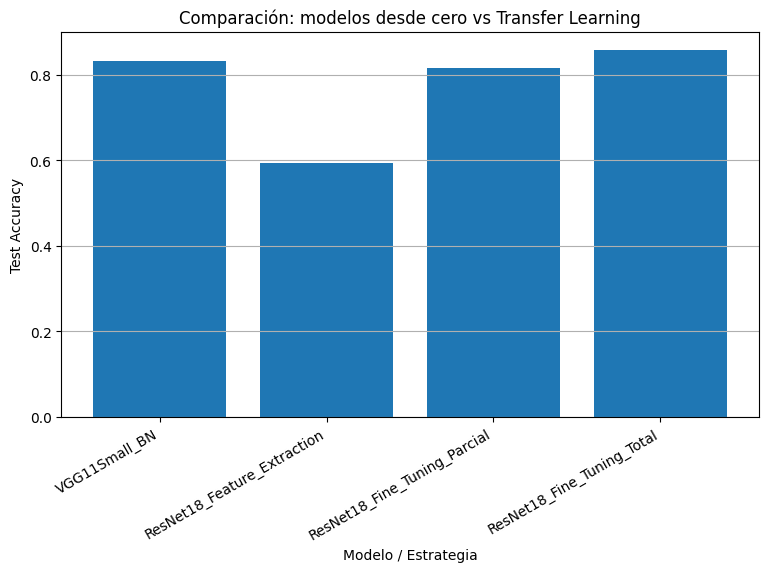

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_comparacion_tarea3["Modelo"],
    df_comparacion_tarea3["Test_accuracy"]
)

plt.xlabel("Modelo / Estrategia")
plt.ylabel("Test Accuracy")
plt.title("Comparación: modelos desde cero vs Transfer Learning")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/tarea3_comparacion_test_accuracy.png", bbox_inches="tight")
plt.show()

In [39]:
best_row = df_comparacion_tarea3.sort_values("Test_accuracy", ascending=False).iloc[0]
best_row

,3
Modelo,ResNet18_Fine_Tuning_Total
Estrategia,fine_tuning_total
Learning_rate,0.00001
Parametros_entrenables,11178564
Tiempo_promedio_epoca_s,36.64
Best_val_accuracy,0.9985
Test_accuracy,0.8577
Test_loss,0.575


## Matriz de confusión del mejor modelo

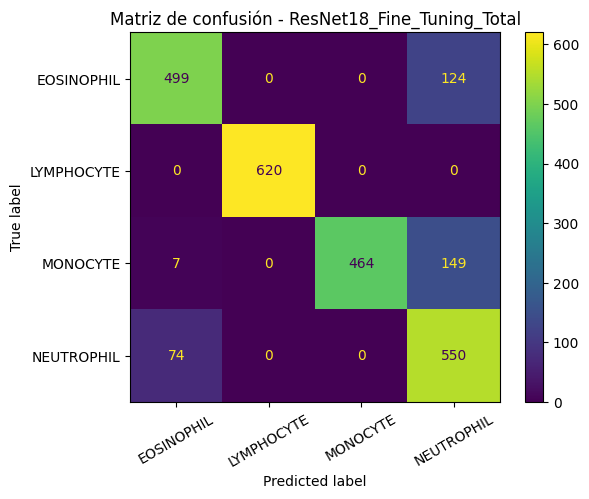

Test Accuracy mejor modelo: 0.8577
              precision    recall  f1-score   support

  EOSINOPHIL       0.86      0.80      0.83       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.67      0.88      0.76       624

    accuracy                           0.86      2487
   macro avg       0.88      0.86      0.86      2487
weighted avg       0.88      0.86      0.86      2487



In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

best_model_name = "ResNet18_Fine_Tuning_Total"

best_model = build_resnet18_transfer(
    strategy="fine_tuning_total",
    num_classes=4
).to(device)

checkpoint_path = f"results/checkpoints/{best_model_name}_best.pth"
best_model = load_best_checkpoint(best_model, checkpoint_path, device)

test_loss, test_acc, test_preds, test_labels = evaluate(
    model=best_model,
    data_loader=test_loader_tl,
    criterion=criterion,
    device=device
)

cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xticks(rotation=30)
plt.savefig("results/figures/matriz_confusion_mejor_modelo.png", bbox_inches="tight")
plt.show()

print("Test Accuracy mejor modelo:", round(test_acc, 4))
print(classification_report(test_labels, test_preds, target_names=class_names))

## Análisis comparativo final de modelos

In [55]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)

df_tarea1 = pd.read_csv("results/metrics/tarea1_resultados.csv")
df_tarea2 = pd.read_csv("results/metrics/tarea2_analisis_learning_rates.csv")
df_tarea3 = pd.read_csv("results/metrics/tarea3_comparacion_con_desde_cero.csv")

print("Resultados Tarea 1")
display(df_tarea1)

print("Resultados Tarea 2")
display(df_tarea2)

print("Resultados Tarea 3")
display(df_tarea3)

Resultados Tarea 1


,Modelo,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,LeNet,337976,13.91,0.8262,0.7479,0.7932
1,LeNet_BN,338020,13.52,0.8825,0.5131,3.5496
2,VGG11Small,2963396,14.14,0.3737,0.3438,1.3740
3,VGG11Small_BN,2966148,14.64,0.9754,0.8331,1.3317


Resultados Tarea 2


,Modelo,Batch_Normalization,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,2963396,14.13,0.2557,0.2505,1.3864
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,2966148,14.43,0.8327,0.8018,0.5163
2,VGG11Small_sin_BN_LR_0.003,sin BN,0.003,2963396,14.03,0.2557,0.2505,1.3868
3,VGG11Small_con_BN_LR_0.003,con BN,0.003,2966148,14.29,0.8614,0.6900,1.0727
4,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,2963396,13.75,0.2557,0.2505,1.3864
5,VGG11Small_con_BN_LR_0.01,con BN,0.010,2966148,14.27,0.7107,0.7193,0.4776


Resultados Tarea 3


,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_BN,Entrenado desde cero,NaN,2966148,14.64,0.9754,0.8331,1.3317
1,ResNet18_Feature_Extraction,feature_extraction,0.00100,2052,29.95,0.7042,0.5943,1.0449
2,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.00010,10495492,30.99,1.0000,0.8154,1.0546
3,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,36.64,0.9985,0.8577,0.5750


## Comparación global de modelos principales

In [56]:
# Mejor modelo desde cero
best_tarea1 = df_tarea1.sort_values("Test_accuracy", ascending=False).iloc[0]

# Mejor resultado de Tarea 2
best_tarea2 = df_tarea2.sort_values("Test_accuracy", ascending=False).iloc[0]

# Modelos de Tarea 3
df_global = pd.DataFrame([
    {
        "Modelo": best_tarea1["Modelo"],
        "Tipo": "CNN desde cero",
        "Test_accuracy": best_tarea1["Test_accuracy"],
        "Best_val_accuracy": best_tarea1["Best_val_accuracy"],
        "Parametros_entrenables": best_tarea1["Parametros_entrenables"]
    },
    {
        "Modelo": best_tarea2["Modelo"],
        "Tipo": "Análisis BN",
        "Test_accuracy": best_tarea2["Test_accuracy"],
        "Best_val_accuracy": best_tarea2["Best_val_accuracy"],
        "Parametros_entrenables": best_tarea2["Parametros_entrenables"]
    }
])

df_transfer_global = df_tarea3.copy()
df_transfer_global = df_transfer_global.rename(columns={
    "Estrategia": "Tipo"
})

df_transfer_global = df_transfer_global[[
    "Modelo",
    "Tipo",
    "Test_accuracy",
    "Best_val_accuracy",
    "Parametros_entrenables"
]]

df_global = pd.concat([df_global, df_transfer_global], ignore_index=True)

df_global.to_csv("results/metrics/resultados_globales_modelos.csv", index=False)

df_global

,Modelo,Tipo,Test_accuracy,Best_val_accuracy,Parametros_entrenables
0,VGG11Small_BN,CNN desde cero,0.8331,0.9754,2966148
1,VGG11Small_con_BN_LR_0.001,Análisis BN,0.8018,0.8327,2966148
2,VGG11Small_BN,Entrenado desde cero,0.8331,0.9754,2966148
3,ResNet18_Feature_Extraction,feature_extraction,0.5943,0.7042,2052
4,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.8154,1.0000,10495492
5,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.8577,0.9985,11178564


## Gráfica global de Test Accuracy

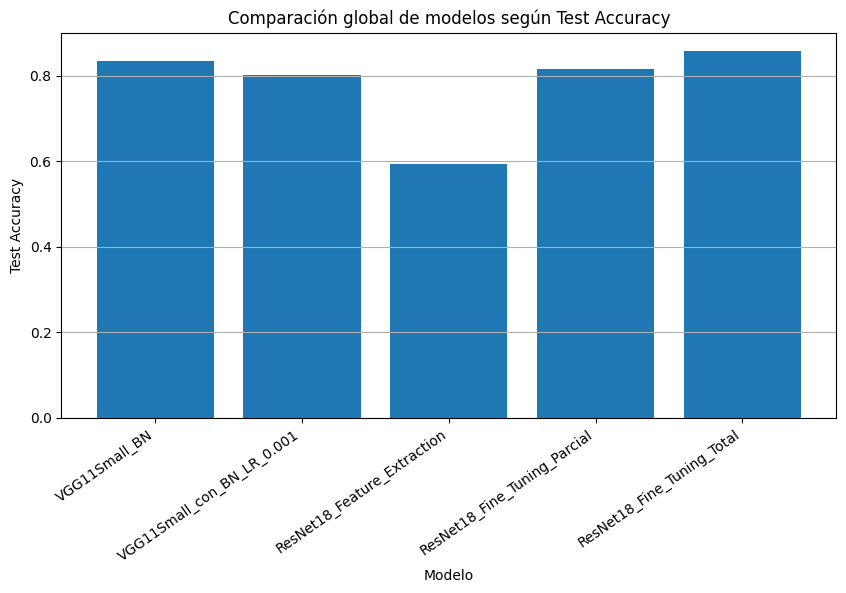

In [57]:
plt.figure(figsize=(10, 5))

plt.bar(df_global["Modelo"], df_global["Test_accuracy"])

plt.xlabel("Modelo")
plt.ylabel("Test Accuracy")
plt.title("Comparación global de modelos según Test Accuracy")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/comparacion_global_test_accuracy.png", bbox_inches="tight")
plt.show()

## Comparación de parámetros vs accuracy

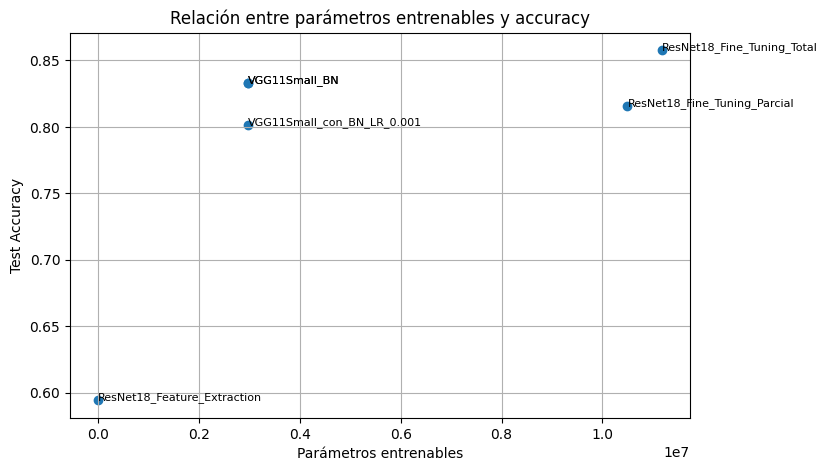

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_global["Parametros_entrenables"],
    df_global["Test_accuracy"]
)

for _, row in df_global.iterrows():
    plt.text(
        row["Parametros_entrenables"],
        row["Test_accuracy"],
        row["Modelo"],
        fontsize=8
    )

plt.xlabel("Parámetros entrenables")
plt.ylabel("Test Accuracy")
plt.title("Relación entre parámetros entrenables y accuracy")
plt.grid(True)

plt.savefig("results/figures/comparacion_parametros_vs_accuracy.png", bbox_inches="tight")
plt.show()

## Comparación Tarea 1: modelos desde cero

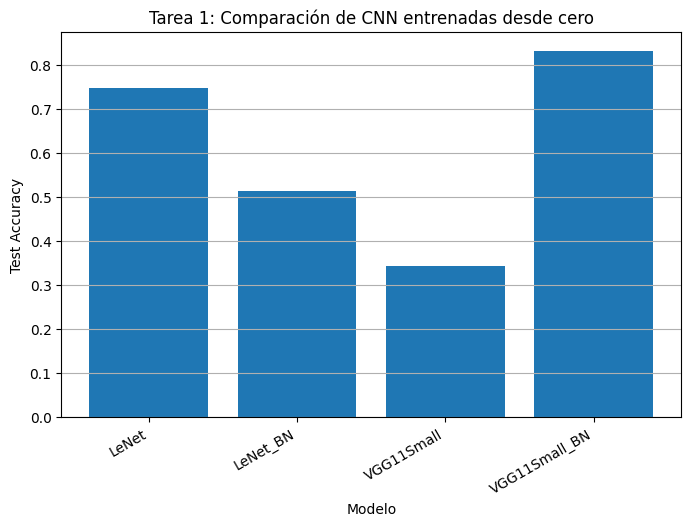

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(df_tarea1["Modelo"], df_tarea1["Test_accuracy"])

plt.xlabel("Modelo")
plt.ylabel("Test Accuracy")
plt.title("Tarea 1: Comparación de CNN entrenadas desde cero")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/tarea1_comparacion_test_accuracy.png", bbox_inches="tight")
plt.show()

## Comparación Tarea 2: efecto de learning rate y BN

In [60]:
df_tarea2_resumen = df_tarea2[[
    "Modelo",
    "Batch_Normalization",
    "Learning_rate",
    "Best_val_accuracy",
    "Test_accuracy",
    "Test_loss"
]]

df_tarea2_resumen.to_csv("results/metrics/tarea2_resumen_informe.csv", index=False)
df_tarea2_resumen

,Modelo,Batch_Normalization,Learning_rate,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_sin_BN_LR_0.001,sin BN,0.001,0.2557,0.2505,1.3864
1,VGG11Small_con_BN_LR_0.001,con BN,0.001,0.8327,0.8018,0.5163
2,VGG11Small_sin_BN_LR_0.003,sin BN,0.003,0.2557,0.2505,1.3868
3,VGG11Small_con_BN_LR_0.003,con BN,0.003,0.8614,0.6900,1.0727
4,VGG11Small_sin_BN_LR_0.01,sin BN,0.010,0.2557,0.2505,1.3864
5,VGG11Small_con_BN_LR_0.01,con BN,0.010,0.7107,0.7193,0.4776


## Comparación Tarea 3: Transfer Learning

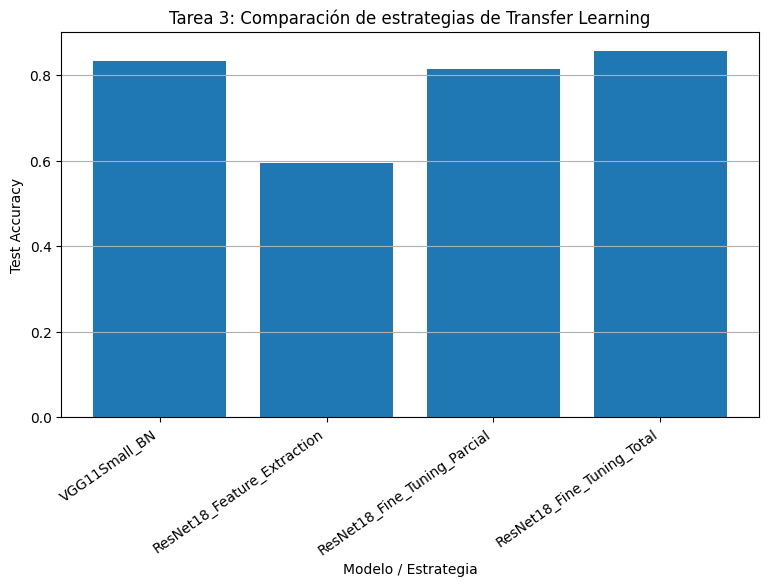

In [61]:
plt.figure(figsize=(9, 5))

plt.bar(df_tarea3["Modelo"], df_tarea3["Test_accuracy"])

plt.xlabel("Modelo / Estrategia")
plt.ylabel("Test Accuracy")
plt.title("Tarea 3: Comparación de estrategias de Transfer Learning")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/tarea3_comparacion_transfer_learning.png", bbox_inches="tight")
plt.show()

## Curva comparativa de pérdida para las 3 estrategias

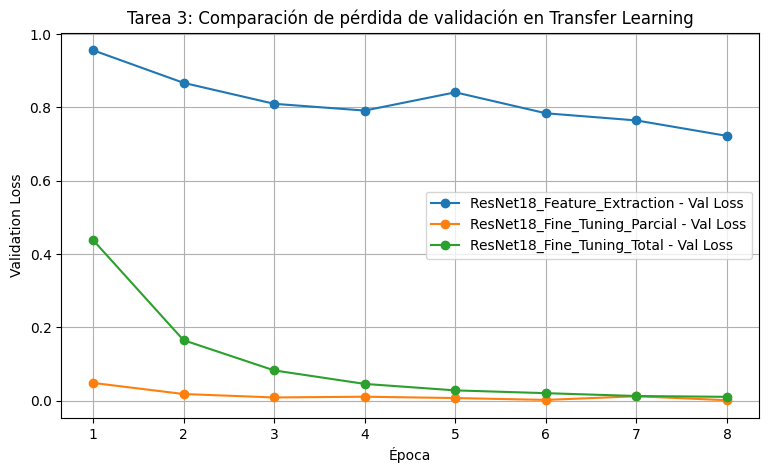

In [62]:
import matplotlib.pyplot as plt
import os

os.makedirs("results/figures", exist_ok=True)

plt.figure(figsize=(9, 5))

for model_name, history in transfer_histories.items():
    epochs_range = range(1, len(history["val_loss"]) + 1)
    plt.plot(
        epochs_range,
        history["val_loss"],
        marker="o",
        label=f"{model_name} - Val Loss"
    )

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Tarea 3: Comparación de pérdida de validación en Transfer Learning")
plt.legend()
plt.grid(True)
plt.savefig("results/figures/tarea3_comparacion_val_loss.png", bbox_inches="tight")
plt.show()

## Curva comparativa de accuracy para las 3 estrategias

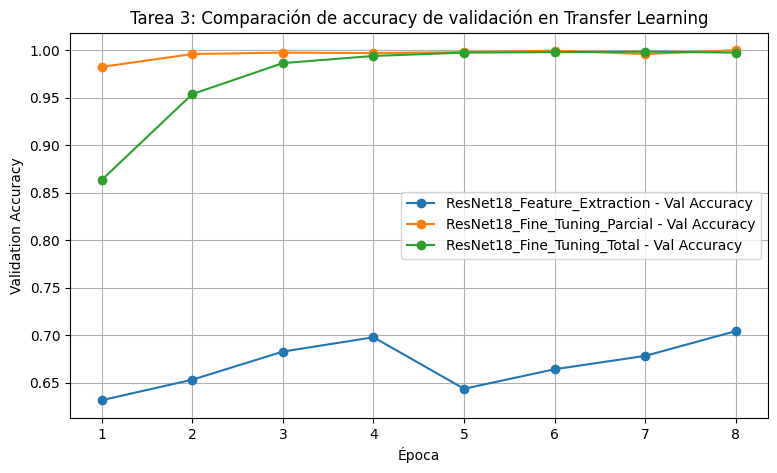

In [63]:
plt.figure(figsize=(9, 5))

for model_name, history in transfer_histories.items():
    epochs_range = range(1, len(history["val_acc"]) + 1)
    plt.plot(
        epochs_range,
        history["val_acc"],
        marker="o",
        label=f"{model_name} - Val Accuracy"
    )

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("Tarea 3: Comparación de accuracy de validación en Transfer Learning")
plt.legend()
plt.grid(True)
plt.savefig("results/figures/tarea3_comparacion_val_accuracy.png", bbox_inches="tight")
plt.show()

## Curvas train vs validation por estrategia

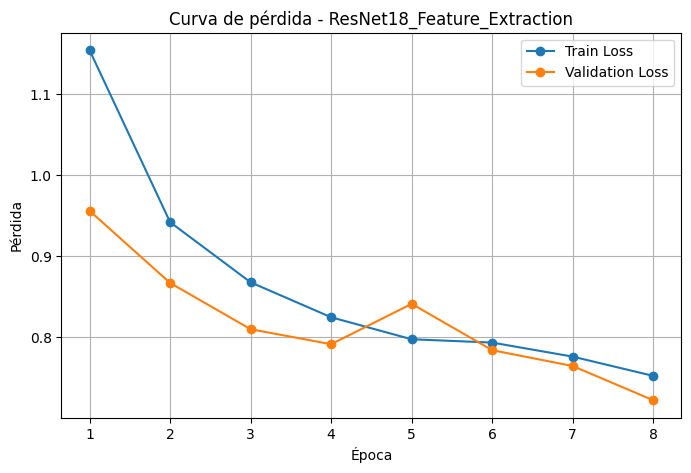

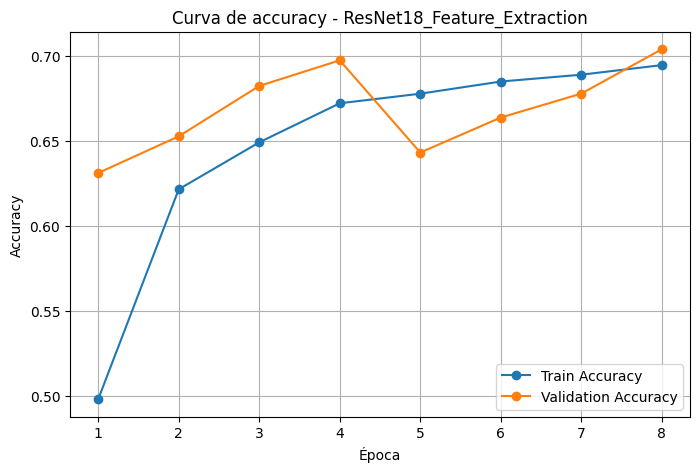

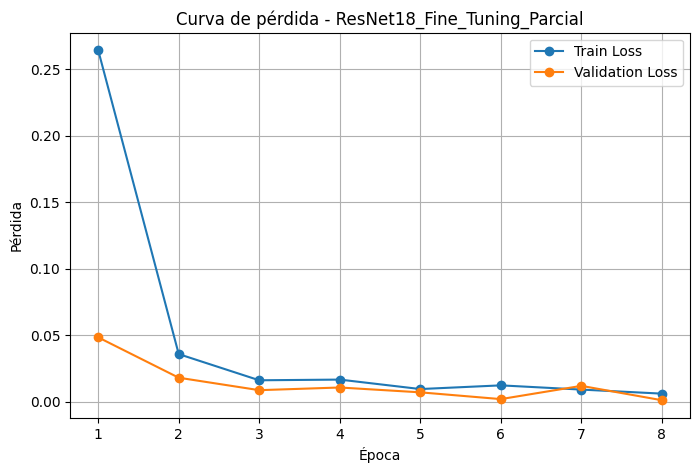

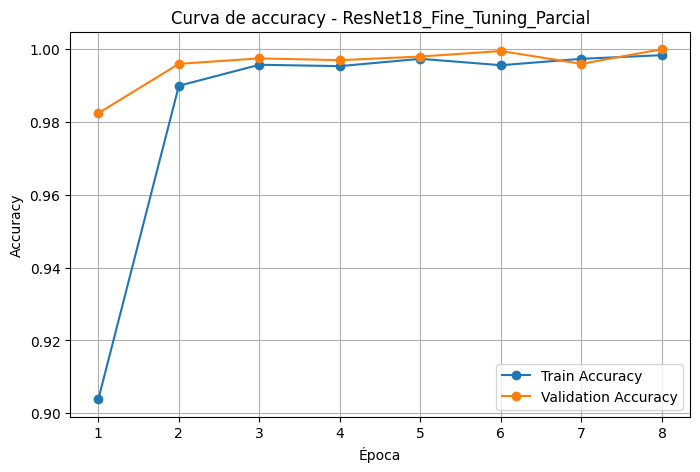

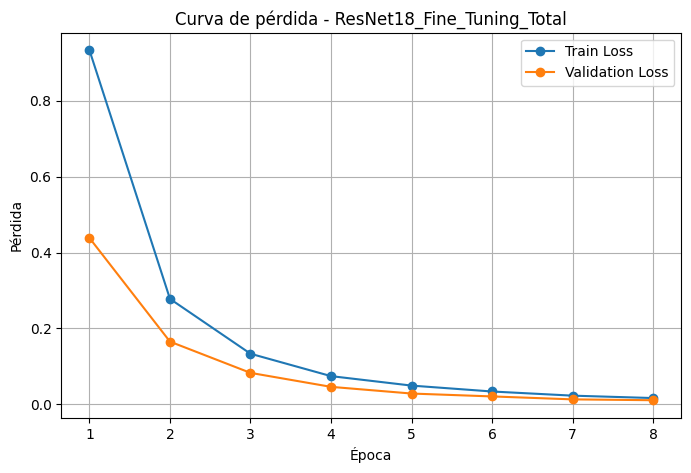

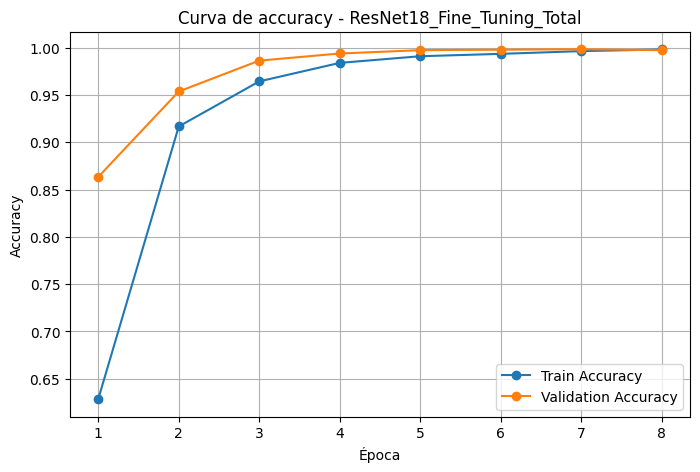

In [64]:
for model_name, history in transfer_histories.items():
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"results/figures/{model_name}_transfer_loss_curve.png", bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"results/figures/{model_name}_transfer_accuracy_curve.png", bbox_inches="tight")
    plt.show()

## Comparación final de Test Accuracy

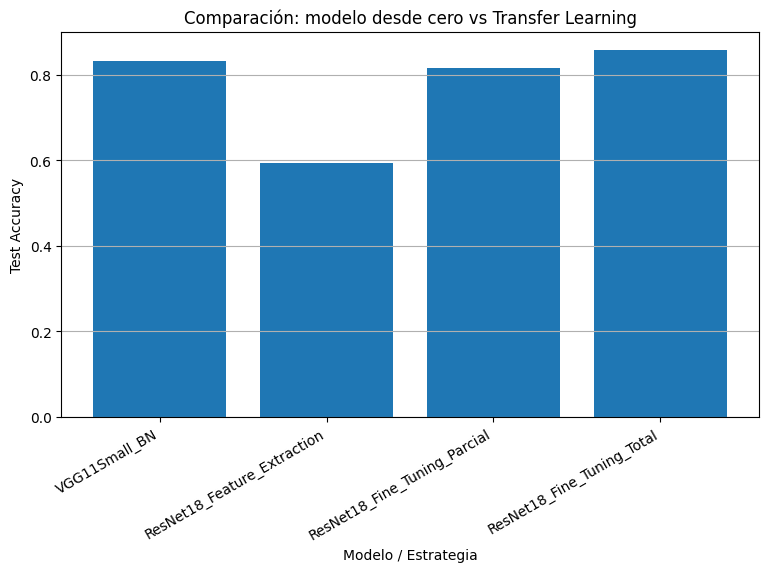

In [65]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_comparacion_tarea3["Modelo"],
    df_comparacion_tarea3["Test_accuracy"]
)

plt.xlabel("Modelo / Estrategia")
plt.ylabel("Test Accuracy")
plt.title("Comparación: modelo desde cero vs Transfer Learning")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/tarea3_comparacion_test_accuracy.png", bbox_inches="tight")
plt.show()

## Gráfica global final para todos los modelos principales

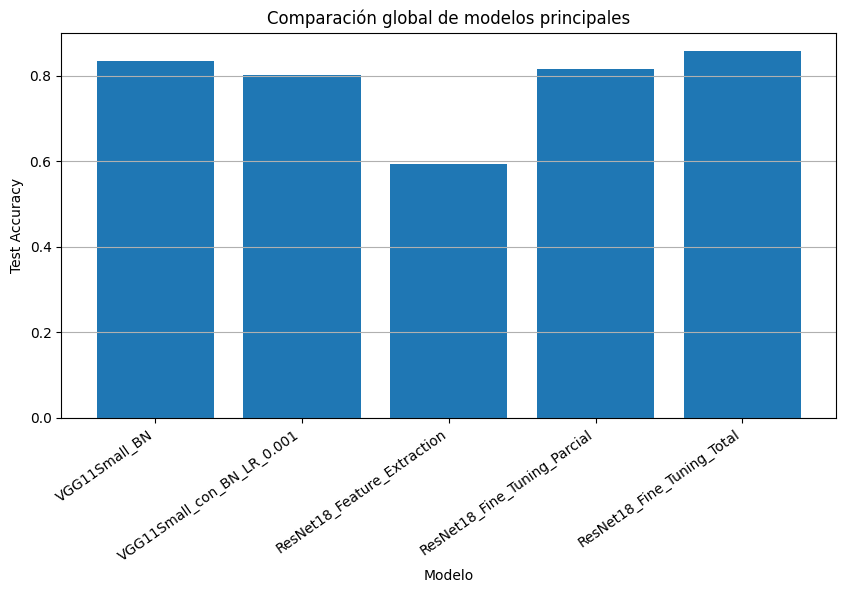

,Modelo,Tipo,Test_accuracy
0,VGG11Small_BN,Mejor CNN desde cero,0.8331
1,VGG11Small_con_BN_LR_0.001,Mejor experimento BN,0.8018
2,VGG11Small_BN,Entrenado desde cero,0.8331
3,ResNet18_Feature_Extraction,feature_extraction,0.5943
4,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.8154
5,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.8577


In [66]:
df_tarea1 = pd.read_csv("results/metrics/tarea1_resultados.csv")
df_tarea2 = pd.read_csv("results/metrics/tarea2_analisis_learning_rates.csv")
df_tarea3 = pd.read_csv("results/metrics/tarea3_comparacion_con_desde_cero.csv")

best_tarea1 = df_tarea1.sort_values("Test_accuracy", ascending=False).iloc[0]
best_tarea2 = df_tarea2.sort_values("Test_accuracy", ascending=False).iloc[0]

df_global = pd.DataFrame([
    {
        "Modelo": best_tarea1["Modelo"],
        "Tipo": "Mejor CNN desde cero",
        "Test_accuracy": best_tarea1["Test_accuracy"]
    },
    {
        "Modelo": best_tarea2["Modelo"],
        "Tipo": "Mejor experimento BN",
        "Test_accuracy": best_tarea2["Test_accuracy"]
    }
])

df_transfer_global = df_tarea3[["Modelo", "Estrategia", "Test_accuracy"]].copy()
df_transfer_global = df_transfer_global.rename(columns={"Estrategia": "Tipo"})

df_global = pd.concat([df_global, df_transfer_global], ignore_index=True)

plt.figure(figsize=(10, 5))
plt.bar(df_global["Modelo"], df_global["Test_accuracy"])
plt.xlabel("Modelo")
plt.ylabel("Test Accuracy")
plt.title("Comparación global de modelos principales")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y")
plt.savefig("results/figures/comparacion_global_modelos.png", bbox_inches="tight")
plt.show()

df_global

# EDA

## 1. Conteo de imágenes por clase

In [41]:
import os
import pandas as pd

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

train_dir = os.path.join(DATA_DIR, "TRAIN")
test_dir = os.path.join(DATA_DIR, "TEST")

def count_images_by_class(split_dir):
    records = []

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]

            records.append({
                "Clase": class_name,
                "Cantidad": len(images)
            })

    return pd.DataFrame(records)

train_counts = count_images_by_class(train_dir)
test_counts = count_images_by_class(test_dir)

print("Distribución en TRAIN")
display(train_counts)

print("Distribución en TEST")
display(test_counts)

Distribución en TRAIN


,Clase,Cantidad
0,EOSINOPHIL,2497
1,LYMPHOCYTE,2483
2,MONOCYTE,2478
3,NEUTROPHIL,2499


Distribución en TEST


,Clase,Cantidad
0,EOSINOPHIL,623
1,LYMPHOCYTE,620
2,MONOCYTE,620
3,NEUTROPHIL,624


## 2. Porcentaje por clase

In [42]:
train_counts["Porcentaje"] = (train_counts["Cantidad"] / train_counts["Cantidad"].sum() * 100).round(2)
test_counts["Porcentaje"] = (test_counts["Cantidad"] / test_counts["Cantidad"].sum() * 100).round(2)

print("TRAIN con porcentajes")
display(train_counts)

print("TEST con porcentajes")
display(test_counts)

TRAIN con porcentajes


,Clase,Cantidad,Porcentaje
0,EOSINOPHIL,2497,25.08
1,LYMPHOCYTE,2483,24.94
2,MONOCYTE,2478,24.89
3,NEUTROPHIL,2499,25.10


TEST con porcentajes


,Clase,Cantidad,Porcentaje
0,EOSINOPHIL,623,25.05
1,LYMPHOCYTE,620,24.93
2,MONOCYTE,620,24.93
3,NEUTROPHIL,624,25.09


In [43]:
distribution_summary = train_counts.merge(
    test_counts,
    on="Clase",
    suffixes=("_TRAIN", "_TEST")
)

distribution_summary

,Clase,Cantidad_TRAIN,Porcentaje_TRAIN,Cantidad_TEST,Porcentaje_TEST
0,EOSINOPHIL,2497,25.08,623,25.05
1,LYMPHOCYTE,2483,24.94,620,24.93
2,MONOCYTE,2478,24.89,620,24.93
3,NEUTROPHIL,2499,25.10,624,25.09


## 3. Gráficas de distribución por clase

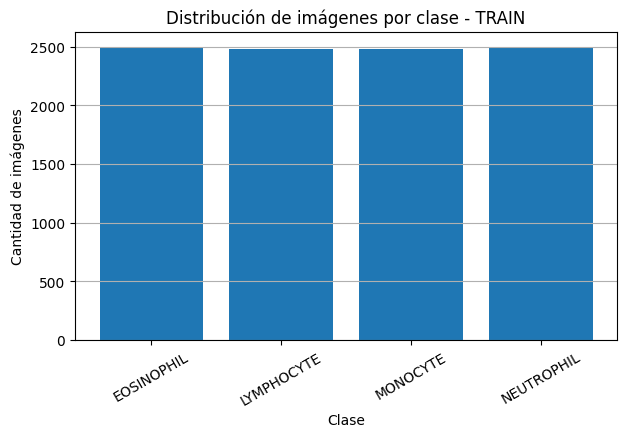

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(train_counts["Clase"], train_counts["Cantidad"])
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - TRAIN")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.savefig("results/figures/eda_distribucion_train.png", bbox_inches="tight")
plt.show()

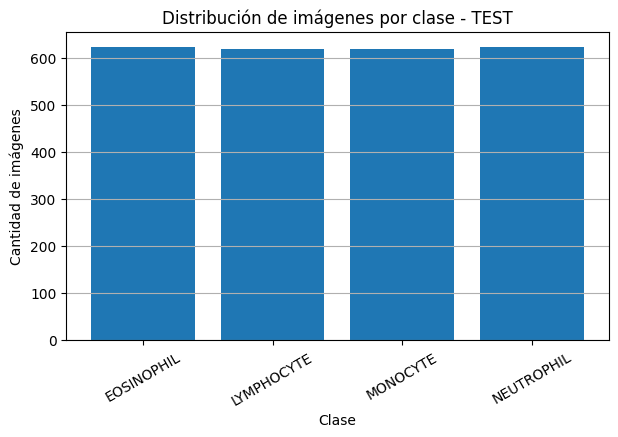

In [45]:
plt.figure(figsize=(7, 4))
plt.bar(test_counts["Clase"], test_counts["Cantidad"])
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase - TEST")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.savefig("results/figures/eda_distribucion_test.png", bbox_inches="tight")
plt.show()

## 4. Comparación TRAIN vs TEST

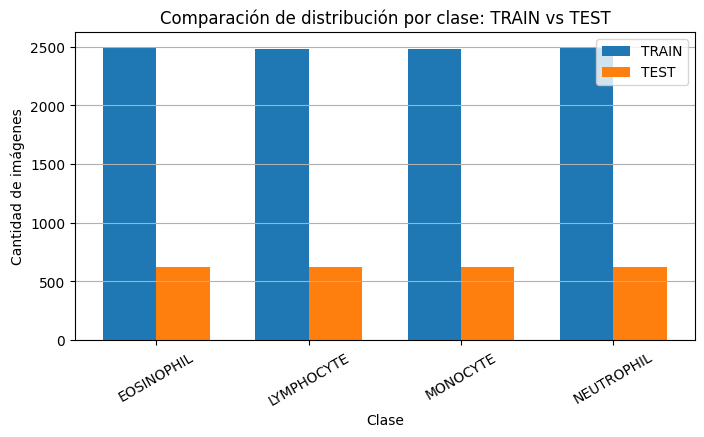

In [46]:
import numpy as np

x = np.arange(len(distribution_summary["Clase"]))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, distribution_summary["Cantidad_TRAIN"], width, label="TRAIN")
plt.bar(x + width/2, distribution_summary["Cantidad_TEST"], width, label="TEST")

plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.title("Comparación de distribución por clase: TRAIN vs TEST")
plt.xticks(x, distribution_summary["Clase"], rotation=30)
plt.legend()
plt.grid(axis="y")
plt.savefig("results/figures/eda_distribucion_train_test.png", bbox_inches="tight")
plt.show()

## 5. Visualización de ejemplos por clase

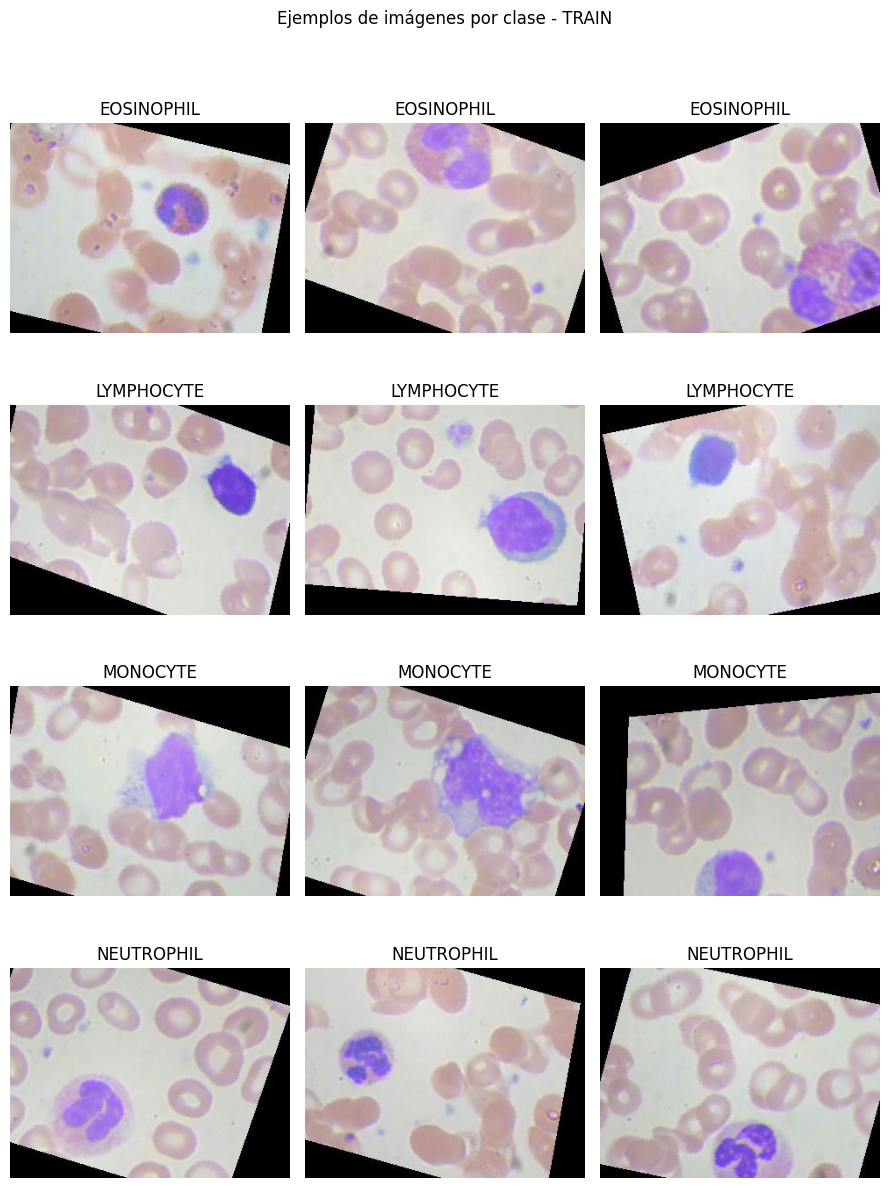

In [47]:
from PIL import Image
import random

def show_sample_images(split_dir, samples_per_class=3):
    class_names = sorted(os.listdir(split_dir))
    total_images = len(class_names) * samples_per_class

    plt.figure(figsize=(samples_per_class * 3, len(class_names) * 3))

    plot_idx = 1

    for class_name in class_names:
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        selected_images = random.sample(image_files, min(samples_per_class, len(image_files)))

        for img_name in selected_images:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)

            plt.subplot(len(class_names), samples_per_class, plot_idx)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

            plot_idx += 1

    plt.suptitle("Ejemplos de imágenes por clase - TRAIN", y=1.02)
    plt.tight_layout()
    plt.savefig("results/figures/eda_ejemplos_por_clase.png", bbox_inches="tight")
    plt.show()

show_sample_images(train_dir, samples_per_class=3)

## 6. Verificar tamaño y modo de imágenes

In [48]:
from PIL import Image
import pandas as pd

def inspect_image_properties(split_dir, max_images_per_class=100):
    records = []

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        image_files = image_files[:max_images_per_class]

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)

            with Image.open(img_path) as img:
                width, height = img.size

                records.append({
                    "Clase": class_name,
                    "Archivo": img_name,
                    "Ancho": width,
                    "Alto": height,
                    "Modo": img.mode,
                    "Formato": img.format
                })

    return pd.DataFrame(records)

image_properties = inspect_image_properties(train_dir, max_images_per_class=100)
image_properties.head()

,Clase,Archivo,Ancho,Alto,Modo,Formato
0,EOSINOPHIL,_68_443.jpeg,320,240,RGB,JPEG
1,EOSINOPHIL,_23_6123.jpeg,320,240,RGB,JPEG
2,EOSINOPHIL,_61_988.jpeg,320,240,RGB,JPEG
3,EOSINOPHIL,_68_4186.jpeg,320,240,RGB,JPEG
4,EOSINOPHIL,_47_7688.jpeg,320,240,RGB,JPEG


### Resumen

In [49]:
image_properties[["Ancho", "Alto"]].describe()

,Ancho,Alto
count,400.0,400.0
mean,320.0,240.0
std,0.0,0.0
min,320.0,240.0
25%,320.0,240.0
50%,320.0,240.0
75%,320.0,240.0
max,320.0,240.0


### Modo de color

In [50]:
image_properties["Modo"].value_counts()

,count
Modo,
RGB,400


### Formato

In [51]:
image_properties["Formato"].value_counts()

,count
Formato,
JPEG,400


## 7. Gráfica de tamaños de imagen

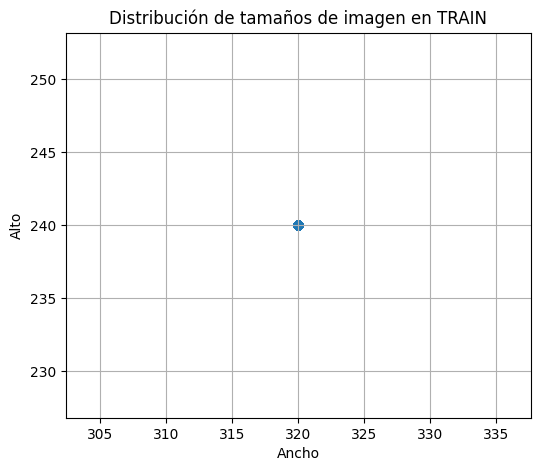

In [52]:
plt.figure(figsize=(6, 5))
plt.scatter(image_properties["Ancho"], image_properties["Alto"], alpha=0.5)
plt.xlabel("Ancho")
plt.ylabel("Alto")
plt.title("Distribución de tamaños de imagen en TRAIN")
plt.grid(True)
plt.savefig("results/figures/eda_tamanios_imagenes.png", bbox_inches="tight")
plt.show()

## 8. Verificar imágenes corruptas

In [53]:
from PIL import Image

def find_corrupted_images(split_dir):
    corrupted = []

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception as e:
                corrupted.append({
                    "Clase": class_name,
                    "Archivo": img_name,
                    "Error": str(e)
                })

    return pd.DataFrame(corrupted)

corrupted_train = find_corrupted_images(train_dir)
corrupted_test = find_corrupted_images(test_dir)

print("Imágenes corruptas en TRAIN:", len(corrupted_train))
print("Imágenes corruptas en TEST:", len(corrupted_test))

display(corrupted_train.head())
display(corrupted_test.head())

Imágenes corruptas en TRAIN: 0
Imágenes corruptas en TEST: 0


""


""


## 9. Guardar resumen del EDA en CSV

In [54]:
os.makedirs("results/metrics", exist_ok=True)

train_counts.to_csv("results/metrics/eda_train_distribution.csv", index=False)
test_counts.to_csv("results/metrics/eda_test_distribution.csv", index=False)
distribution_summary.to_csv("results/metrics/eda_distribution_summary.csv", index=False)
image_properties.to_csv("results/metrics/eda_image_properties_sample.csv", index=False)